In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train_data = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Training dataset:", train_data.shape)
print("Validation dataset:", validation_data.shape)

Training dataset: (79328, 45)
Validation dataset: (8648, 45)


In [3]:
if "is_fraud" not in train_data.columns:
    raise ValueError(
        "is_fraud column is missing from training data."
    )

if "is_fraud" not in validation_data.columns:
    raise ValueError(
        "is_fraud column is missing from validation data."
    )

print("Target column found successfully!")

Target column found successfully!


In [4]:
X_train = train_data.drop(
    columns=["is_fraud"]
)

y_train = train_data["is_fraud"]

X_validation = validation_data.drop(
    columns=["is_fraud"]
)

y_validation = validation_data["is_fraud"]

In [5]:
common_columns = [
    column for column in X_train.columns
    if column in X_validation.columns
]

if len(common_columns) == 0:
    raise ValueError(
        "No common feature columns were found."
    )

X_train = X_train[common_columns].copy()
X_validation = X_validation[common_columns].copy()

print("Common features:", len(common_columns))

Common features: 44


In [6]:
for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

print("Features converted to numeric.")

Features converted to numeric.


In [7]:
usable_columns = [
    column for column in X_train.columns
    if X_train[column].notna().any()
]

if len(usable_columns) == 0:
    raise ValueError(
        "No usable numeric features were found."
    )

X_train = X_train[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

print("Usable features:", len(usable_columns))
print(usable_columns)

Usable features: 22
['amount', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'transaction_hour', 'transaction_day', 'transaction_month', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'login_attempts', 'account_age_days', 'email_age_days', 'failed_payment_attempts', 'customer_balance', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']


In [8]:
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

y_validation = pd.to_numeric(
    y_validation,
    errors="coerce"
)

valid_train_rows = y_train.notna()
valid_validation_rows = y_validation.notna()

X_train = X_train.loc[
    valid_train_rows
].reset_index(drop=True)

y_train = y_train.loc[
    valid_train_rows
].astype(int).reset_index(drop=True)

X_validation = X_validation.loc[
    valid_validation_rows
].reset_index(drop=True)

y_validation = y_validation.loc[
    valid_validation_rows
].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [9]:
training_medians = X_train.median()

X_train = X_train.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

X_train = X_train.fillna(0)
X_validation = X_validation.fillna(0)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

print("Feature scaling completed!")

Feature scaling completed!


In [11]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

print("SVM model created successfully!")

SVM model created successfully!


In [12]:
svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully!")

SVM model trained successfully!


In [13]:
svm_predictions = svm_model.predict(
    X_validation_scaled
)

svm_scores = svm_model.decision_function(
    X_validation_scaled
)

print("SVM predictions created successfully!")

SVM predictions created successfully!


In [14]:
svm_accuracy = accuracy_score(
    y_validation,
    svm_predictions
)

svm_precision = precision_score(
    y_validation,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_validation,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_validation,
    svm_predictions,
    zero_division=0
)

svm_roc_auc = roc_auc_score(
    y_validation,
    svm_scores
)

print("SVM FRAUD DETECTION RESULTS")
print("---------------------------")
print("Accuracy:", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall:", round(svm_recall, 4))
print("F1 Score:", round(svm_f1, 4))
print("ROC-AUC:", round(svm_roc_auc, 4))

SVM FRAUD DETECTION RESULTS
---------------------------
Accuracy: 0.695
Precision: 0.0313
Recall: 0.557
F1 Score: 0.0592
ROC-AUC: 0.655


In [15]:
print(
    classification_report(
        y_validation,
        svm_predictions,
        labels=[0, 1],
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.70      0.82      8499
       Fraud       0.03      0.56      0.06       149

    accuracy                           0.69      8648
   macro avg       0.51      0.63      0.44      8648
weighted avg       0.97      0.69      0.80      8648



In [16]:
svm_confusion = confusion_matrix(
    y_validation,
    svm_predictions,
    labels=[0, 1]
)

print(svm_confusion)

[[5927 2572]
 [  66   83]]


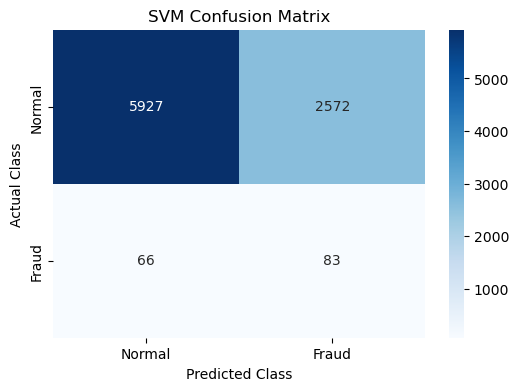

In [17]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    svm_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

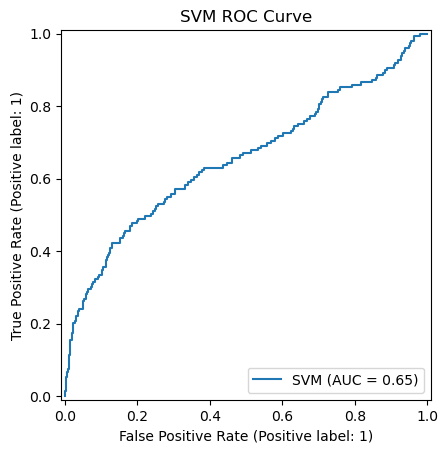

In [18]:
RocCurveDisplay.from_predictions(
    y_validation,
    svm_scores,
    name="SVM"
)

plt.title("SVM ROC Curve")
plt.show()

In [19]:
svm_results = pd.DataFrame({
    "model": ["SVM"],
    "accuracy": [svm_accuracy],
    "precision": [svm_precision],
    "recall": [svm_recall],
    "f1_score": [svm_f1],
    "roc_auc": [svm_roc_auc]
})

svm_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,SVM,0.695,0.0313,0.557,0.0592,0.655


In [20]:
svm_results.to_csv(
    "svm_fraud_results.csv",
    index=False
)

print("SVM results saved successfully!")

SVM results saved successfully!


In [21]:
result_files = [
    "day10_logistic_regression_results.csv",
    "fraud_model_comparison.csv",
    "xgboost_fraud_results.csv",
    "optimized_xgboost_results.csv",
    "svm_fraud_results.csv"
]

available_files = [
    file for file in result_files
    if os.path.exists(file)
]

print("Available result files:")

for file in available_files:
    print(file)

Available result files:
day10_logistic_regression_results.csv
fraud_model_comparison.csv
xgboost_fraud_results.csv
optimized_xgboost_results.csv
svm_fraud_results.csv


In [22]:
def prepare_result_file(file_name):

    result = pd.read_csv(file_name)

    result.columns = (
        result.columns
        .str.strip()
        .str.lower()
    )

    result = result.rename(columns={
        "f1": "f1_score",
        "roc-auc": "roc_auc",
        "roc_auc_score": "roc_auc"
    })

    required_columns = [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]

    available_columns = [
        column for column in required_columns
        if column in result.columns
    ]

    return result[available_columns]

In [23]:
model_tables = []

for file in available_files:

    result_table = prepare_result_file(file)

    if "model" in result_table.columns:
        model_tables.append(result_table)

if len(model_tables) == 0:
    all_model_results = svm_results.copy()
else:
    all_model_results = pd.concat(
        model_tables,
        ignore_index=True
    )

all_model_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression Baseline,0.689524,0.031412,0.570470,0.059545,0.655596
1,Decision Tree,0.848404,0.046802,0.402685,0.083857,0.613979
2,Random Forest,0.878353,0.055172,0.375839,0.096220,0.650585
3,XGBoost,0.839154,0.040680,0.369128,0.073284,0.646499
4,Optimized XGBoost,0.908534,0.060274,0.295302,0.100114,0.627245
5,SVM,0.694958,0.031262,0.557047,0.059201,0.654966


In [24]:
all_model_results = (
    all_model_results
    .drop_duplicates(
        subset=["model"],
        keep="last"
    )
    .reset_index(drop=True)
)

numeric_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

for column in numeric_metrics:

    if column in all_model_results.columns:

        all_model_results[column] = pd.to_numeric(
            all_model_results[column],
            errors="coerce"
        )

all_model_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression Baseline,0.6895,0.0314,0.5705,0.0595,0.6556
1,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
2,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506
3,XGBoost,0.8392,0.0407,0.3691,0.0733,0.6465
4,Optimized XGBoost,0.9085,0.0603,0.2953,0.1001,0.6272
5,SVM,0.6950,0.0313,0.5570,0.0592,0.6550


In [25]:
comparison_data = all_model_results.dropna(
    subset=["f1_score"]
)

if comparison_data.empty:
    raise ValueError(
        "No valid F1 scores were found."
    )

best_model_row = comparison_data.loc[
    comparison_data["f1_score"].idxmax()
]

print(
    "Best validation model:",
    best_model_row["model"]
)

print(
    "Best F1 Score:",
    round(best_model_row["f1_score"], 4)
)

Best validation model: Optimized XGBoost
Best F1 Score: 0.1001


In [26]:
comparison_table = all_model_results[[
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]].copy()

comparison_table = comparison_table.sort_values(
    by="f1_score",
    ascending=False
).reset_index(drop=True)

comparison_table.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Optimized XGBoost,0.9085,0.0603,0.2953,0.1001,0.6272
1,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506
2,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
3,XGBoost,0.8392,0.0407,0.3691,0.0733,0.6465
4,Logistic Regression Baseline,0.6895,0.0314,0.5705,0.0595,0.6556
5,SVM,0.6950,0.0313,0.5570,0.0592,0.6550


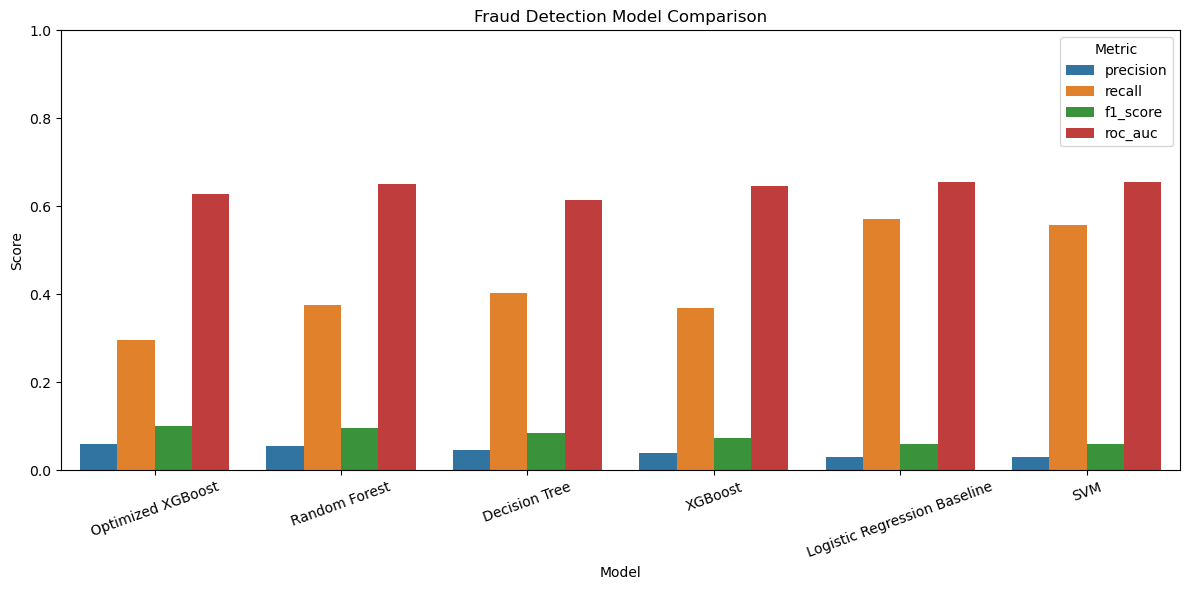

In [27]:
comparison_long = comparison_table.melt(
    id_vars="model",
    value_vars=[
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Fraud Detection Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [28]:
comparison_table.to_csv(
    "final_fraud_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully!")

Final model comparison saved successfully!
